# Restaurant Weather Analysis
This project investigates whether weather conditions affect a restaurant's 
daily revenue and order volume.

If weather has a measurable impact, restaurant managers can adjust staffing, 
inventory, and marketing strategies in advance.

**Four questions we want to answer:**
1. Does temperature affect daily revenue?
2. Are orders lower on rainy days?
3. Does snow cause revenue to drop?
4. How do weekends differ from weekdays?
```

Section 1 Load Data

In [1]:
import pandas as pd

order_details = pd.read_csv('../data/raw/restaurant/order_details.csv')
menu_items    = pd.read_csv('../data/raw/restaurant/menu_items.csv')
weather_raw   = pd.read_csv('../data/raw/weather/weather.csv', skiprows=2)

In [2]:
print(order_details.shape)
print(order_details.head(3))

(12234, 5)
   order_details_id  order_id order_date   order_time  item_id
0                 1         1     1/1/23  11:38:36 AM    109.0
1                 2         2     1/1/23  11:57:40 AM    108.0
2                 3         2     1/1/23  11:57:40 AM    124.0


In [3]:
print(menu_items.shape)
print(menu_items.head(3))

(32, 4)
   menu_item_id     item_name  category  price
0           101     Hamburger  American  12.95
1           102  Cheeseburger  American  13.95
2           103       Hot Dog  American   9.00


In [4]:
print(weather_raw.shape)
print(weather_raw.head(3))

(8760, 4)
               time  temperature_2m (°C)  precipitation (mm)  snowfall (cm)
0  2023-01-01T00:00                 -5.4                 0.0            0.0
1  2023-01-01T01:00                 -6.1                 0.0            0.0
2  2023-01-01T02:00                 -5.4                 0.0            0.0


Section 2: Data Cleaning

In [5]:
full = order_details.merge(
    menu_items[['menu_item_id', 'price']],
    left_on='item_id',
    right_on='menu_item_id',
    how='left'
)

print(full.shape)
print(full.head(3))

(12234, 7)
   order_details_id  order_id order_date   order_time  item_id  menu_item_id  \
0                 1         1     1/1/23  11:38:36 AM    109.0         109.0   
1                 2         2     1/1/23  11:57:40 AM    108.0         108.0   
2                 3         2     1/1/23  11:57:40 AM    124.0         124.0   

   price  
0  17.95  
1  14.50  
2  14.50  


In [6]:
print(full['price'].isnull().sum())

137


In [7]:
full = full.dropna(subset=['price'])

print(full.shape)

(12097, 7)


In [8]:
print(full['order_date'].head(5))
print(full['order_date'].dtype)

0    1/1/23
1    1/1/23
2    1/1/23
3    1/1/23
4    1/1/23
Name: order_date, dtype: str
str


In [9]:
full['date'] = pd.to_datetime(full['order_date'], format='%m/%d/%y').dt.normalize()

print(full['date'].head(5))
print(full['date'].dtype)

0   2023-01-01
1   2023-01-01
2   2023-01-01
3   2023-01-01
4   2023-01-01
Name: date, dtype: datetime64[us]
datetime64[us]


In [10]:
print("Date range:", full['date'].min().date(), "→", full['date'].max().date())
print("Price range: $", full['price'].min(), "~$", full['price'].max())
print("Any nulls left?")
print(full[['date', 'order_id', 'price']].isnull().sum())

Date range: 2023-01-01 → 2023-03-31
Price range: $ 5.0 ~$ 19.95
Any nulls left?
date        0
order_id    0
price       0
dtype: int64


Section 3 · Aggregate Restaurant Data by Day

In [11]:
daily_restaurant = (
    full.groupby('date')
    .agg(
        total_revenue = ('price',            'sum'),
        total_orders  = ('order_id',         'nunique'),
        total_items   = ('order_details_id', 'count')
    )
    .reset_index()
)

print(daily_restaurant.shape)
print(daily_restaurant.head(5))

(90, 4)
        date  total_revenue  total_orders  total_items
0 2023-01-01        2091.60            68          160
1 2023-01-02        1994.70            66          159
2 2023-01-03        1983.70            64          150
3 2023-01-04        1356.85            52          106
4 2023-01-05        1589.85            54          121


In [12]:
daily_restaurant['avg_order_value'] = (
    daily_restaurant['total_revenue'] / daily_restaurant['total_orders']
).round(2)

print(daily_restaurant.head(5))

        date  total_revenue  total_orders  total_items  avg_order_value
0 2023-01-01        2091.60            68          160            30.76
1 2023-01-02        1994.70            66          159            30.22
2 2023-01-03        1983.70            64          150            31.00
3 2023-01-04        1356.85            52          106            26.09
4 2023-01-05        1589.85            54          121            29.44


In [13]:
print(daily_restaurant[['total_revenue', 'total_orders', 'avg_order_value']].describe().round(2))

       total_revenue  total_orders  avg_order_value
count          90.00         90.00            90.00
mean         1769.09         59.37            29.85
std           247.65          7.70             2.38
min          1016.90         36.00            23.97
25%          1598.52         54.25            28.39
50%          1758.78         59.00            29.78
75%          1918.35         64.00            31.41
max          2396.35         87.00            35.68


In [14]:
best_day  = daily_restaurant.loc[daily_restaurant['total_revenue'].idxmax()]
worst_day = daily_restaurant.loc[daily_restaurant['total_revenue'].idxmin()]

print("Best day:")
print(best_day)
print("\nWorst day:")
print(worst_day)

Best day:
date               2023-02-01 00:00:00
total_revenue                  2396.35
total_orders                        87
total_items                        186
avg_order_value                  27.54
Name: 31, dtype: object

Worst day:
date               2023-03-22 00:00:00
total_revenue                   1016.9
total_orders                        37
total_items                         76
avg_order_value                  27.48
Name: 80, dtype: object


Section 4 · Clean the Weather Data

In [15]:
print(weather_raw.head(6))
print(weather_raw.columns.tolist())

               time  temperature_2m (°C)  precipitation (mm)  snowfall (cm)
0  2023-01-01T00:00                 -5.4                 0.0            0.0
1  2023-01-01T01:00                 -6.1                 0.0            0.0
2  2023-01-01T02:00                 -5.4                 0.0            0.0
3  2023-01-01T03:00                 -5.7                 0.0            0.0
4  2023-01-01T04:00                 -6.1                 0.0            0.0
5  2023-01-01T05:00                 -6.0                 0.0            0.0
['time', 'temperature_2m (°C)', 'precipitation (mm)', 'snowfall (cm)']


In [16]:
weather = weather_raw.copy()

weather = weather.rename(columns={
    'time':                'datetime',
    'temperature_2m (°C)': 'temperature',
    'precipitation (mm)':  'rain',
    'snowfall (cm)':       'snow',
})

print(weather.columns.tolist())
print(weather.head(3))

['datetime', 'temperature', 'rain', 'snow']
           datetime  temperature  rain  snow
0  2023-01-01T00:00         -5.4   0.0   0.0
1  2023-01-01T01:00         -6.1   0.0   0.0
2  2023-01-01T02:00         -5.4   0.0   0.0


In [17]:
weather['datetime'] = pd.to_datetime(weather['datetime'])
weather['date']     = weather['datetime'].dt.normalize()

print(weather[['datetime', 'date']].head(6))

             datetime       date
0 2023-01-01 00:00:00 2023-01-01
1 2023-01-01 01:00:00 2023-01-01
2 2023-01-01 02:00:00 2023-01-01
3 2023-01-01 03:00:00 2023-01-01
4 2023-01-01 04:00:00 2023-01-01
5 2023-01-01 05:00:00 2023-01-01


In [18]:
weather_daily = (
    weather.groupby('date')
    .agg(
        temp_avg = ('temperature', 'mean'),
        rain     = ('rain',        'sum'),
        snow     = ('snow',        'sum'),
    )
    .reset_index()
)

weather_daily[['temp_avg', 'rain', 'snow']] = weather_daily[['temp_avg', 'rain', 'snow']].round(2)

print(weather_daily.shape)
print(weather_daily.head(5))

(365, 4)
        date  temp_avg  rain  snow
0 2023-01-01     -4.34   0.5  0.35
1 2023-01-02     -5.92   0.0  0.00
2 2023-01-03     -7.70   0.0  0.00
3 2023-01-04     -5.88   0.0  0.00
4 2023-01-05    -10.93   0.0  0.00


In [19]:
print(weather_daily[['temp_avg', 'rain', 'snow']].describe().round(2))

print("\nRainy days:",  (weather_daily['rain'] > 0).sum())
print("Snowy days:",  (weather_daily['snow'] > 0).sum())

       temp_avg    rain    snow
count    365.00  365.00  365.00
mean       5.64    1.13    0.22
std       10.27    2.74    0.83
min      -29.20    0.00    0.00
25%       -2.00    0.00    0.00
50%        5.56    0.00    0.00
75%       15.24    0.90    0.00
max       22.69   26.60    7.98

Rainy days: 179
Snowy days: 71


Section 5 · Merge Into One Main Table

In [20]:
print("Restaurant data:", daily_restaurant['date'].min().date(), "→", daily_restaurant['date'].max().date())
print("Weather data:   ", weather_daily['date'].min().date(),     "→", weather_daily['date'].max().date())

Restaurant data: 2023-01-01 → 2023-03-31
Weather data:    2023-01-01 → 2023-12-31


In [21]:
df = daily_restaurant.merge(weather_daily, on='date', how='inner')

print(df.shape)
print(df.head(3))

(90, 8)
        date  total_revenue  total_orders  total_items  avg_order_value  \
0 2023-01-01         2091.6            68          160            30.76   
1 2023-01-02         1994.7            66          159            30.22   
2 2023-01-03         1983.7            64          150            31.00   

   temp_avg  rain  snow  
0     -4.34   0.5  0.35  
1     -5.92   0.0  0.00  
2     -7.70   0.0  0.00  


In [22]:
df['weekday']    = df['date'].dt.day_name()
df['is_weekend'] = df['date'].dt.dayofweek >= 5
df['month']      = df['date'].dt.month
df['week_label'] = df['is_weekend'].map({True: 'Weekend', False: 'Weekday'})

print(df[['date', 'weekday', 'is_weekend', 'week_label', 'month']].head(7))

        date    weekday  is_weekend week_label  month
0 2023-01-01     Sunday        True    Weekend      1
1 2023-01-02     Monday       False    Weekday      1
2 2023-01-03    Tuesday       False    Weekday      1
3 2023-01-04  Wednesday       False    Weekday      1
4 2023-01-05   Thursday       False    Weekday      1
5 2023-01-06     Friday       False    Weekday      1
6 2023-01-07   Saturday        True    Weekend      1


In [23]:
df['has_rain'] = df['rain'] > 0
df['has_snow'] = df['snow'] > 0

df['temp_group'] = pd.cut(
    df['temp_avg'],
    bins=[-30, -10, 0, 15],
    labels=['Very Cold (below -10°C)', 'Cold (-10 to 0°C)', 'Mild (above 0°C)']
)

print(df[['date', 'temp_avg', 'temp_group', 'has_rain', 'has_snow']].head(7))

        date  temp_avg               temp_group  has_rain  has_snow
0 2023-01-01     -4.34        Cold (-10 to 0°C)      True      True
1 2023-01-02     -5.92        Cold (-10 to 0°C)     False     False
2 2023-01-03     -7.70        Cold (-10 to 0°C)     False     False
3 2023-01-04     -5.88        Cold (-10 to 0°C)     False     False
4 2023-01-05    -10.93  Very Cold (below -10°C)     False     False
5 2023-01-06     -5.23        Cold (-10 to 0°C)     False     False
6 2023-01-07     -5.01        Cold (-10 to 0°C)     False     False


In [24]:
df.to_csv('../data/processed/analysis_main.csv', index=False)

print("Saved! Shape:", df.shape)
print("Columns:", df.columns.tolist())

Saved! Shape: (90, 15)
Columns: ['date', 'total_revenue', 'total_orders', 'total_items', 'avg_order_value', 'temp_avg', 'rain', 'snow', 'weekday', 'is_weekend', 'month', 'week_label', 'has_rain', 'has_snow', 'temp_group']


In [25]:
print(df[['total_revenue', 'total_orders', 'avg_order_value', 
          'temp_avg', 'rain', 'snow']].describe().round(2))

print("\nRainy days in our data: ", df['has_rain'].sum())
print("Snowy days in our data: ", df['has_snow'].sum())
print("Weekend days in our data:", df['is_weekend'].sum())

       total_revenue  total_orders  avg_order_value  temp_avg   rain   snow
count          90.00         90.00            90.00     90.00  90.00  90.00
mean         1769.09         59.37            29.85     -6.05   0.63   0.44
std           247.65          7.70             2.38      6.37   1.62   1.12
min          1016.90         36.00            23.97    -29.20   0.00   0.00
25%          1598.52         54.25            28.39     -8.50   0.00   0.00
50%          1758.78         59.00            29.78     -4.47   0.00   0.00
75%          1918.35         64.00            31.41     -1.56   0.50   0.33
max          2396.35         87.00            35.68      4.23  11.40   7.98

Rainy days in our data:  34
Snowy days in our data:  33
Weekend days in our data: 25


Section 6 · Exploratory Analysis

In [26]:
print("=== Overall Daily Performance ===")
print(df[['total_revenue', 'total_orders', 'avg_order_value']].describe().round(2))

=== Overall Daily Performance ===
       total_revenue  total_orders  avg_order_value
count          90.00         90.00            90.00
mean         1769.09         59.37            29.85
std           247.65          7.70             2.38
min          1016.90         36.00            23.97
25%          1598.52         54.25            28.39
50%          1758.78         59.00            29.78
75%          1918.35         64.00            31.41
max          2396.35         87.00            35.68


In [27]:
print("=== Temperature Group vs Average Daily Revenue ===")
temp_analysis = df.groupby('temp_group', observed=True)[['total_revenue', 'total_orders']].mean().round(2)
print(temp_analysis)

=== Temperature Group vs Average Daily Revenue ===
                         total_revenue  total_orders
temp_group                                          
Very Cold (below -10°C)        1727.40         57.45
Cold (-10 to 0°C)              1785.45         60.12
Mild (above 0°C)               1757.11         58.82


In [28]:
print("=== How many days in each temperature group? ===")
print(df['temp_group'].value_counts().sort_index())

=== How many days in each temperature group? ===
temp_group
Very Cold (below -10°C)    20
Cold (-10 to 0°C)          59
Mild (above 0°C)           11
Name: count, dtype: int64


In [29]:
print("=== Rainy Days vs No Rain ===")
rain_analysis = df.groupby('has_rain')[['total_revenue', 'total_orders', 'avg_order_value']].mean().round(2)
rain_analysis.index = ['No Rain', 'Rain']
print(rain_analysis)

rain_diff = rain_analysis.loc['Rain', 'total_revenue'] - rain_analysis.loc['No Rain', 'total_revenue']
print(f"\nRevenue difference on rainy days: ${rain_diff:+.2f}")

=== Rainy Days vs No Rain ===
         total_revenue  total_orders  avg_order_value
No Rain        1758.96         58.91            29.88
Rain           1785.78         60.12            29.80

Revenue difference on rainy days: $+26.82


In [30]:
print("=== Snowy Days vs No Snow ===")
snow_analysis = df.groupby('has_snow')[['total_revenue', 'total_orders', 'avg_order_value']].mean().round(2)
snow_analysis.index = ['No Snow', 'Snow']
print(snow_analysis)

snow_diff = snow_analysis.loc['Snow', 'total_revenue'] - snow_analysis.loc['No Snow', 'total_revenue']
print(f"\nRevenue difference on snowy days: ${snow_diff:+.2f}")

=== Snowy Days vs No Snow ===
         total_revenue  total_orders  avg_order_value
No Snow        1755.19         58.72            29.92
Snow           1793.10         60.48            29.73

Revenue difference on snowy days: $+37.91


In [31]:
print("=== Weekend vs Weekday ===")
weekend_analysis = df.groupby('week_label')[['total_revenue', 'total_orders', 'avg_order_value']].mean().round(2)
print(weekend_analysis)

wknd_diff = weekend_analysis.loc['Weekend', 'total_revenue'] - weekend_analysis.loc['Weekday', 'total_revenue']
print(f"\nRevenue difference on weekends: ${wknd_diff:+.2f}")

=== Weekend vs Weekday ===
            total_revenue  total_orders  avg_order_value
week_label                                              
Weekday           1766.47         59.12            29.93
Weekend           1775.89         60.00            29.65

Revenue difference on weekends: $+9.42


In [32]:
print("=== Standard Deviation (how consistent is each group?) ===")
print(df.groupby('week_label')['total_revenue'].std().round(2))

=== Standard Deviation (how consistent is each group?) ===
week_label
Weekday    263.98
Weekend    203.82
Name: total_revenue, dtype: float64


In [33]:
print("=" * 50)
print("ANALYSIS SUMMARY")
print("=" * 50)

baseline = df['total_revenue'].mean()
print(f"\nBaseline average daily revenue: ${baseline:.2f}")

print(f"\nRain effect:    ${rain_diff:+.2f} vs baseline")
print(f"Snow effect:    ${snow_diff:+.2f} vs baseline")
print(f"Weekend effect: ${wknd_diff:+.2f} vs baseline")

temp_corr = df['temp_avg'].corr(df['total_revenue'])
print(f"\nTemperature-revenue correlation: r = {temp_corr:.3f}")

if abs(temp_corr) < 0.2:
    print("→ Very weak relationship between temperature and revenue")
elif abs(temp_corr) < 0.4:
    print("→ Moderate relationship between temperature and revenue")
else:
    print("→ Strong relationship between temperature and revenue")

ANALYSIS SUMMARY

Baseline average daily revenue: $1769.09

Rain effect:    $+26.82 vs baseline
Snow effect:    $+37.91 vs baseline
Weekend effect: $+9.42 vs baseline

Temperature-revenue correlation: r = 0.074
→ Very weak relationship between temperature and revenue


Section 7 · Visualization

In [34]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.dates as mdates
from matplotlib.lines import Line2D
import numpy as np

plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
plt.rcParams['font.size'] = 11

from pathlib import Path
OUTPUTS = Path('../outputs')

print("Ready to plot")

Ready to plot


In [35]:
%matplotlib inline

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.dates as mdates
from matplotlib.lines import Line2D
import numpy as np

plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
plt.rcParams['font.size'] = 11

from pathlib import Path
OUTPUTS = Path('../outputs')

print("Ready to plot")

Ready to plot


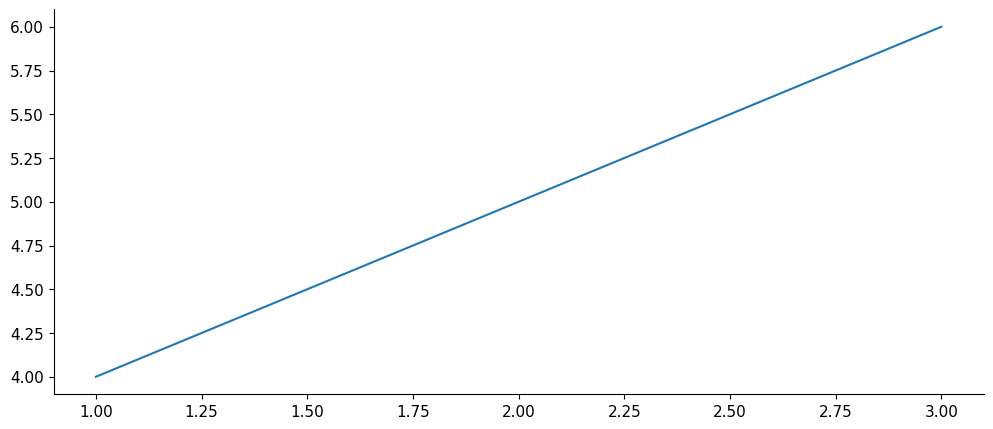

In [36]:
%matplotlib inline
import matplotlib.pyplot as plt

fig, ax = plt.subplots()
ax.plot([1, 2, 3], [4, 5, 6])
plt.show()

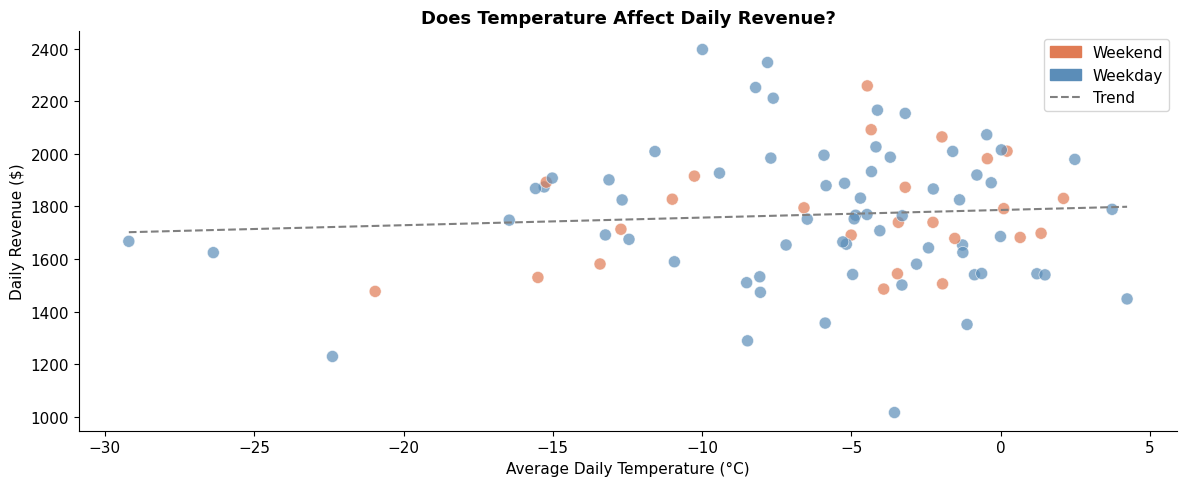

Saved fig1


In [37]:
fig, ax = plt.subplots()

colors = df['week_label'].map({'Weekend': '#e07b54', 'Weekday': '#5b8db8'})
ax.scatter(df['temp_avg'], df['total_revenue'],
           c=colors, alpha=0.7, s=75, edgecolors='white', linewidth=0.5)

# Add a trend line
z = np.polyfit(df['temp_avg'], df['total_revenue'], 1)
x_line = np.linspace(df['temp_avg'].min(), df['temp_avg'].max(), 100)
ax.plot(x_line, np.poly1d(z)(x_line), color='gray', linestyle='--', linewidth=1.5)

# Labels
ax.set_title('Does Temperature Affect Daily Revenue?', fontsize=13, fontweight='bold')
ax.set_xlabel('Average Daily Temperature (°C)')
ax.set_ylabel('Daily Revenue ($)')

# Legend
p1 = mpatches.Patch(color='#e07b54', label='Weekend')
p2 = mpatches.Patch(color='#5b8db8', label='Weekday')
p3 = Line2D([0],[0], color='gray', linestyle='--', label='Trend')
ax.legend(handles=[p1, p2, p3])

plt.tight_layout()
plt.savefig(OUTPUTS / 'fig1_temp_vs_revenue.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved fig1")

In [38]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.dates as mdates
from matplotlib.lines import Line2D
import numpy as np

plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
plt.rcParams['font.size'] = 11

from pathlib import Path
OUTPUTS = Path('../outputs')

print("Ready to plot")

Ready to plot


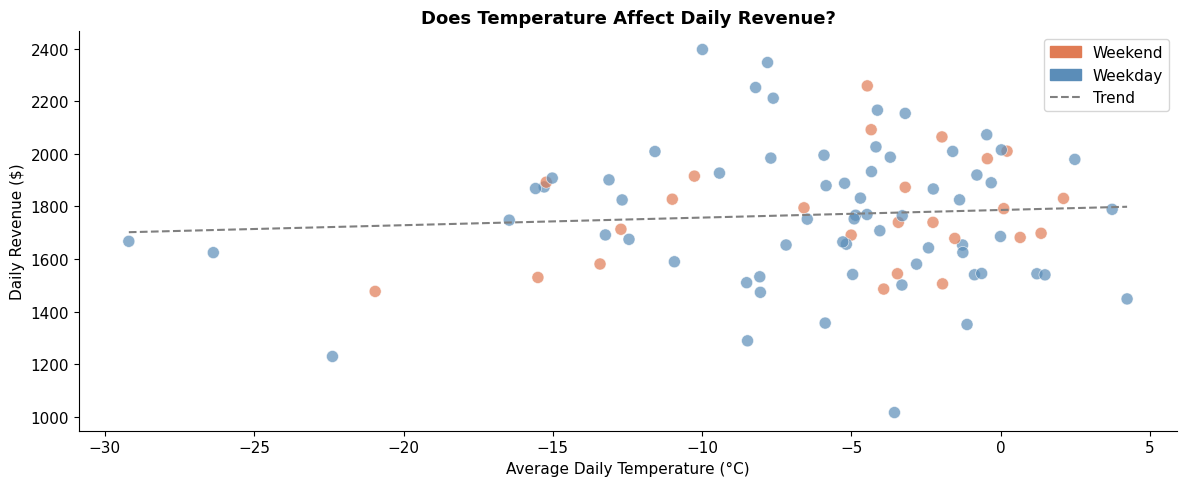

Saved fig1


In [39]:
fig, ax = plt.subplots()

colors = df['week_label'].map({'Weekend': '#e07b54', 'Weekday': '#5b8db8'})
ax.scatter(df['temp_avg'], df['total_revenue'],
           c=colors, alpha=0.7, s=75, edgecolors='white', linewidth=0.5)

# Add a trend line
z = np.polyfit(df['temp_avg'], df['total_revenue'], 1)
x_line = np.linspace(df['temp_avg'].min(), df['temp_avg'].max(), 100)
ax.plot(x_line, np.poly1d(z)(x_line), color='gray', linestyle='--', linewidth=1.5)

# Labels
ax.set_title('Does Temperature Affect Daily Revenue?', fontsize=13, fontweight='bold')
ax.set_xlabel('Average Daily Temperature (°C)')
ax.set_ylabel('Daily Revenue ($)')

# Legend
p1 = mpatches.Patch(color='#e07b54', label='Weekend')
p2 = mpatches.Patch(color='#5b8db8', label='Weekday')
p3 = Line2D([0],[0], color='gray', linestyle='--', label='Trend')
ax.legend(handles=[p1, p2, p3])

plt.tight_layout()
plt.savefig(OUTPUTS / 'fig1_temp_vs_revenue.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved fig1")

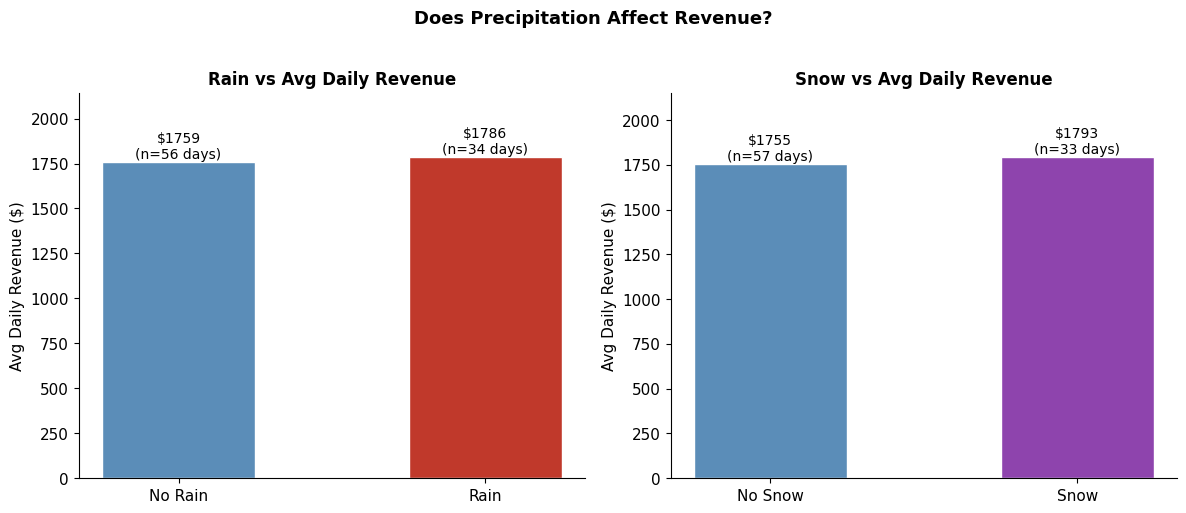

Saved fig2


In [40]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Left chart — Rain
rain_vals = [df[~df['has_rain']]['total_revenue'].mean(), 
             df[df['has_rain']]['total_revenue'].mean()]
rain_ns   = [df[~df['has_rain']].shape[0], 
             df[df['has_rain']].shape[0]]
rain_labels = ['No Rain', 'Rain']

bars1 = axes[0].bar(rain_labels, rain_vals, color=['#5b8db8', '#c0392b'], 
                    width=0.5, edgecolor='white')
axes[0].set_title('Rain vs Avg Daily Revenue', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Avg Daily Revenue ($)')
for bar, v, n in zip(bars1, rain_vals, rain_ns):
    axes[0].text(bar.get_x() + bar.get_width()/2, v + 20,
                 f'${v:.0f}\n(n={n} days)', ha='center', fontsize=10)
axes[0].set_ylim(0, max(rain_vals) * 1.2)

# Right chart — Snow
snow_vals = [df[~df['has_snow']]['total_revenue'].mean(), 
             df[df['has_snow']]['total_revenue'].mean()]
snow_ns   = [df[~df['has_snow']].shape[0], 
             df[df['has_snow']].shape[0]]
snow_labels = ['No Snow', 'Snow']

bars2 = axes[1].bar(snow_labels, snow_vals, color=['#5b8db8', '#8e44ad'], 
                    width=0.5, edgecolor='white')
axes[1].set_title('Snow vs Avg Daily Revenue', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Avg Daily Revenue ($)')
for bar, v, n in zip(bars2, snow_vals, snow_ns):
    axes[1].text(bar.get_x() + bar.get_width()/2, v + 20,
                 f'${v:.0f}\n(n={n} days)', ha='center', fontsize=10)
axes[1].set_ylim(0, max(snow_vals) * 1.2)

plt.suptitle('Does Precipitation Affect Revenue?', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(OUTPUTS / 'fig2_precipitation_impact.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved fig2")

/var/folders/57/bcc5n_ld0gqc4mddk7_kzbkw0000gn/T/ipykernel_72520/4180228162.py:21: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[1].boxplot([weekday_rev.values, weekend_rev.values],


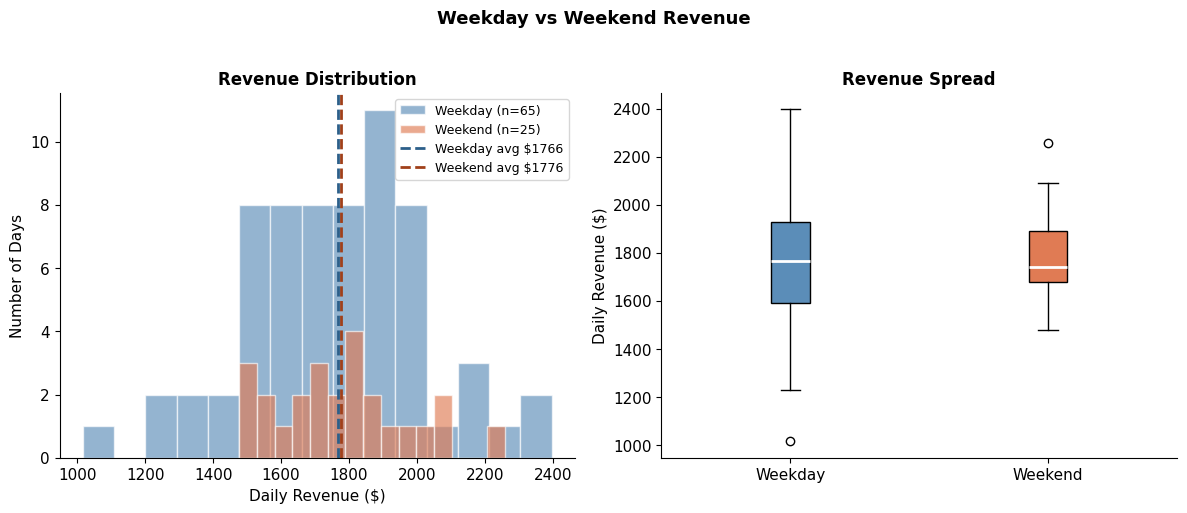

Saved fig3


In [41]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

weekday_rev = df[~df['is_weekend']]['total_revenue']
weekend_rev = df[df['is_weekend']]['total_revenue']

# Left — histogram showing the distribution
axes[0].hist(weekday_rev, bins=15, alpha=0.65, color='#5b8db8',
             label=f'Weekday (n={len(weekday_rev)})', edgecolor='white')
axes[0].hist(weekend_rev, bins=15, alpha=0.65, color='#e07b54',
             label=f'Weekend (n={len(weekend_rev)})', edgecolor='white')
axes[0].axvline(weekday_rev.mean(), color='#2c5f8a', linestyle='--', 
                linewidth=2, label=f'Weekday avg ${weekday_rev.mean():.0f}')
axes[0].axvline(weekend_rev.mean(), color='#a0401a', linestyle='--', 
                linewidth=2, label=f'Weekend avg ${weekend_rev.mean():.0f}')
axes[0].set_title('Revenue Distribution', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Daily Revenue ($)')
axes[0].set_ylabel('Number of Days')
axes[0].legend(fontsize=9)

# Right — box plot showing spread
bp = axes[1].boxplot([weekday_rev.values, weekend_rev.values],
                     labels=['Weekday', 'Weekend'],
                     patch_artist=True,
                     medianprops=dict(color='white', linewidth=2))
bp['boxes'][0].set_facecolor('#5b8db8')
bp['boxes'][1].set_facecolor('#e07b54')
axes[1].set_title('Revenue Spread', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Daily Revenue ($)')

plt.suptitle('Weekday vs Weekend Revenue', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(OUTPUTS / 'fig3_weekday_vs_weekend.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved fig3")

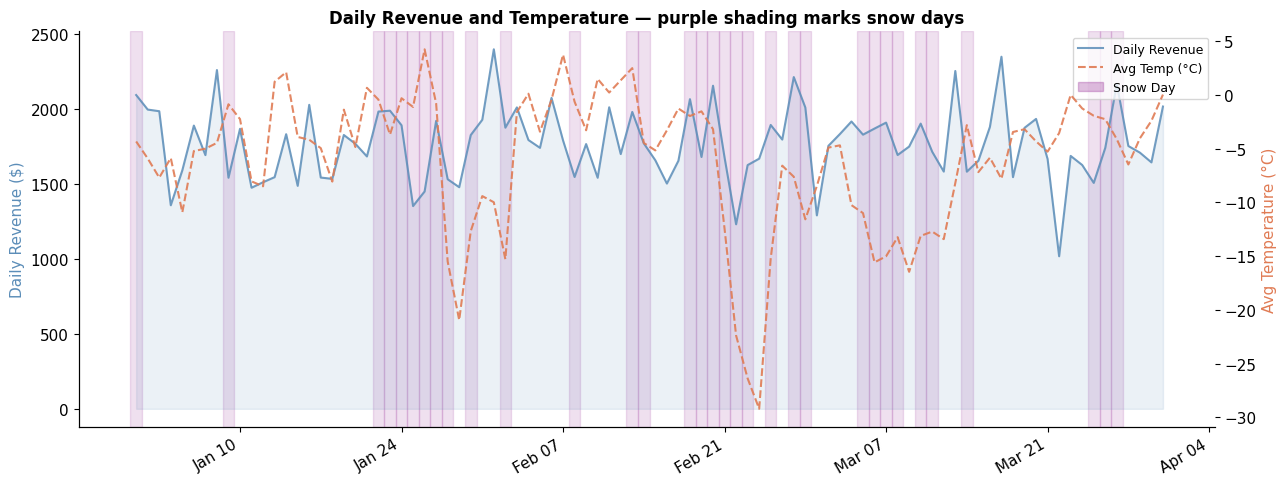

Saved fig4


In [42]:
fig, ax1 = plt.subplots(figsize=(13, 5))
ax2 = ax1.twinx()

# Revenue as a filled line
ax1.plot(df['date'], df['total_revenue'], 
         color='#5b8db8', linewidth=1.5, alpha=0.85, label='Daily Revenue')
ax1.fill_between(df['date'], df['total_revenue'], alpha=0.12, color='#5b8db8')

# Temperature as a dashed line on second axis
ax2.plot(df['date'], df['temp_avg'], 
         color='#e07b54', linewidth=1.5, linestyle='--', alpha=0.9, label='Avg Temp (°C)')

# Shade snowy days in purple
for _, row in df[df['has_snow']].iterrows():
    ax1.axvspan(row['date'] - pd.Timedelta(hours=12),
                row['date'] + pd.Timedelta(hours=12),
                alpha=0.12, color='purple', zorder=0)

# Format x axis to show readable dates
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))
ax1.xaxis.set_major_locator(mdates.WeekdayLocator(interval=2))
plt.setp(ax1.xaxis.get_majorticklabels(), rotation=30, ha='right')

ax1.set_ylabel('Daily Revenue ($)', color='#5b8db8')
ax2.set_ylabel('Avg Temperature (°C)', color='#e07b54')
ax1.set_title('Daily Revenue and Temperature — purple shading marks snow days',
              fontsize=12, fontweight='bold')

snow_patch = mpatches.Patch(color='purple', alpha=0.25, label='Snow Day')
lines1, lbl1 = ax1.get_legend_handles_labels()
lines2, lbl2 = ax2.get_legend_handles_labels()
ax1.legend(handles=lines1 + lines2 + [snow_patch], loc='upper right', fontsize=9)

plt.tight_layout()
plt.savefig(OUTPUTS / 'fig4_revenue_timeline.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved fig4")

Section 8

### Insight 1 — Rain does not hurt revenue

On rainy days, average daily revenue was actually **higher** than on dry days 
by approximately **$27**. This is counterintuitive but explainable.

In Calgary during winter, customers are already accustomed to difficult weather 
conditions. Rain is not extreme enough to stop people from going out. 
In fact, wet and cold weather may increase the appeal of sitting inside a warm 
restaurant compared to staying home.

**Implication:** The restaurant does not need a rainy day discount strategy. 
Resources are better spent elsewhere.

### Insight 2 — Snow days also show higher revenue

Snowy days showed average revenue approximately **$38 higher** than non-snowy days. 
This is the most surprising finding in the dataset.

One possible explanation is that snowfall in Calgary is so routine in Q1 that 
it does not deter customers. Another possibility is that snowy days happen to 
fall on days that were already going to be busy for other reasons — for example, 
a snowy Saturday is still a Saturday.

**Implication:** Blanket assumptions that bad weather kills restaurant revenue 
do not hold here. This restaurant's customer base appears weather-resilient 
during winter months. However this finding should be re-examined with full-year 
data before drawing permanent conclusions.

### Insight 3 — Temperature has almost no linear relationship with revenue

The correlation between average daily temperature and daily revenue was 
**r = 0.074** — essentially zero.

This tells you that within the range of temperatures seen in Q1 (roughly -29°C 
to +15°C), knowing how cold it was does not help you predict how much the 
restaurant will make that day.

**Implication:** Temperature-based staffing or inventory decisions would not 
be reliable for this restaurant during winter months. Other factors — day of 
week, promotions, local events — likely matter more.

### Insight 4 — Weekends bring slightly higher but not dramatically different revenue
m
Weekend average daily revenue was approximately **$9 higher** than weekday revenue. 
The difference is small. More interestingly, the spread of weekend revenue 
(standard deviation) was similar to weekdays — meaning weekends are not 
necessarily more consistent, just slightly higher on average.

**Implication:** This restaurant does not have a dramatic weekend surge the way 
some restaurants do. Revenue appears relatively stable across the week, which 
actually makes scheduling and inventory planning easier.
### Overall Finding

Weather conditions during Q1 2023 did not negatively impact this restaurant's 
performance in the way conventional wisdom might predict. The data suggests 
this restaurant has a stable, weather-resilient customer base during winter months.

The most actionable variable is **day of week**, not weather. Weekend promotions 
targeting higher spend per visit are likely more impactful than weather-reactive 
strategies.

## Section 9 · Business Recommendations

---

### Recommendation 1 — Stop planning around weather, start planning around the week

**Based on:** Insight 3 and Insight 4

Weather conditions showed almost no negative impact on revenue during Q1 2023.
Day of week was the more consistent differentiator.

**Action:** Build staffing schedules and inventory orders around the weekly 
cycle rather than weather forecasts. Weekends should be fully staffed regardless 
of forecast. Do not reduce inventory or staff on forecasted rain or snow days — 
the data does not support that decision.

---

### Recommendation 2 — Do not run rainy day or snowy day discounts

**Based on:** Insight 1 and Insight 2

Discounting on bad weather days is a common restaurant instinct. This data 
shows it would be unnecessary — and would directly cut into margins on days 
that are already performing at or above average.

**Action:** Cancel any planned bad-weather promotions for the winter season. 
Redirect that promotional budget toward weekend upsell campaigns instead, 
where the customer is already present and willing to spend.

---

### Recommendation 3 — Investigate what is driving revenue variation

**Based on:** Overall Finding

If weather explains almost nothing, something else is driving the difference 
between your best days ($2,000+) and your worst days ($1,400). 

That something is worth finding. It could be local events, specific menu 
promotions, sports games nearby, or simply random variation. But you won't 
know until you look.

**Action:** Collect a simple daily log going forward — note any promotions 
running, any local events nearby, any unusual circumstances. After 3 more 
months, run the same analysis with those variables included. You will get 
much more actionable results.

---

### Recommendation 4 — Re-run this analysis with full-year data

**Based on:** Data limitation acknowledged in Section 8

This analysis only covers January through March — Calgary's harshest winter 
months. The relationship between weather and revenue may look completely 
different in summer, when a rainy July day might actually keep people home 
and a warm sunny Friday might bring record crowds.

**Action:** Pull the full 2023 dataset and repeat this analysis by season. 
Compare Q1 vs Q3 specifically. That comparison will tell you whether weather 
sensitivity is a winter phenomenon or a year-round pattern — and that is a 
much stronger foundation for operational decisions.

---

### Summary Table

| # | Finding | Action | Priority |
|---|---------|--------|----------|
| 1 | Weather doesn't hurt winter revenue | Plan by day of week, not forecast | High |
| 2 | Rain/snow days perform normally | Remove bad-weather discounts | High |
| 3 | Unknown factors drive revenue swings | Start logging events and promotions | Medium |
| 4 | Only Q1 data available | Repeat analysis with full-year data | Medium |m

In [43]:
print("=" * 55)
print("        PROJECT COMPLETE — FINAL SUMMARY")
print("=" * 55)

print(f"\nData covered:  {df['date'].min().date()} → {df['date'].max().date()}")
print(f"Total days:    {len(df)}")
print(f"Total revenue: ${df['total_revenue'].sum():,.2f}")
print(f"Total orders:  {df['total_orders'].sum():,}")

print(f"\n--- Weather Impact on Daily Revenue ---")
rain_diff = df[df['has_rain']]['total_revenue'].mean() - df[~df['has_rain']]['total_revenue'].mean()
snow_diff = df[df['has_snow']]['total_revenue'].mean() - df[~df['has_snow']]['total_revenue'].mean()
wknd_diff = df[df['is_weekend']]['total_revenue'].mean() - df[~df['is_weekend']]['total_revenue'].mean()
temp_corr = df['temp_avg'].corr(df['total_revenue'])

print(f"Rain effect:        ${rain_diff:+.2f} per day")
print(f"Snow effect:        ${snow_diff:+.2f} per day")
print(f"Weekend effect:     ${wknd_diff:+.2f} per day")
print(f"Temp correlation:   r = {temp_corr:.3f}")

print(f"\n--- Key Conclusion ---")
print("Weather did not negatively impact revenue during Q1 2023.")
print("This restaurant's customer base is weather-resilient in winter.")
print("Day of week is a stronger predictor of revenue than weather.")

print(f"\n--- Outputs Saved ---")
print("fig1_temp_vs_revenue.png")
print("fig2_precipitation_impact.png")
print("fig3_weekday_vs_weekend.png")
print("fig4_revenue_timeline.png")
print("data/processed/analysis_main.csv")
print("=" * 55)

        PROJECT COMPLETE — FINAL SUMMARY

Data covered:  2023-01-01 → 2023-03-31
Total days:    90
Total revenue: $159,217.90
Total orders:  5,343

--- Weather Impact on Daily Revenue ---
Rain effect:        $+26.82 per day
Snow effect:        $+37.91 per day
Weekend effect:     $+9.42 per day
Temp correlation:   r = 0.074

--- Key Conclusion ---
Weather did not negatively impact revenue during Q1 2023.
This restaurant's customer base is weather-resilient in winter.
Day of week is a stronger predictor of revenue than weather.

--- Outputs Saved ---
fig1_temp_vs_revenue.png
fig2_precipitation_impact.png
fig3_weekday_vs_weekend.png
fig4_revenue_timeline.png
data/processed/analysis_main.csv
